In [1]:
from cherrypick.orchestrator import Orchestrator
from cherrypick.preprocessing import Preprocessor
from cherrypick.anomaly import OutlierPruner
from cherrypick.splits import splitter
from cherrypick.explain import bar_plot, summary_plot, explainer
import warnings
warnings.filterwarnings('ignore')

c:\Cherrypick\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 400, 350, 120, 370, 220, 260, 310, 180, 420, 360],
    "feature_3": [1, None, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, None, 35, 29],
    "target":     [100, 111, 222, 500, 899, 641, 112, 400, 10000, 80000, 190, 133, 112, 41, 1]
    # "target" : [1, 2, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 0, 2, 1]
})

In [3]:
df.isna().sum()

feature_1    0
feature_2    0
feature_3    1
feature_4    0
feature_5    1
target       0
dtype: int64

## Oulier removal

In [4]:
df


,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,12,100,1.0,5,10.0,100
1,45,200,NaN,3,20.0,111
2,23,150,1.0,6,15.0,222
3,67,300,0.0,2,25.0,500
4,34,250,1.0,7,18.0,899
5,89,400,0.0,1,30.0,641
6,54,350,1.0,8,28.0,112
7,21,120,0.0,4,12.0,400
8,76,370,1.0,9,27.0,10000
9,38,220,1.0,5,19.0,80000


In [5]:
outlier = OutlierPruner(df = df, col='target', method='isoforest')
df = outlier.remove_outlier()


In [6]:
df

,feature_1,feature_2,feature_3,feature_4,feature_5,target
1,45,200,NaN,3,20.0,111
2,23,150,1.0,6,15.0,222
3,67,300,0.0,2,25.0,500
4,34,250,1.0,7,18.0,899
5,89,400,0.0,1,30.0,641
6,54,350,1.0,8,28.0,112
10,49,260,0.0,6,22.0,190
11,62,310,1.0,7,24.0,133
12,28,180,0.0,3,NaN,112
14,55,360,0.0,8,29.0,1


In [7]:
process = Preprocessor(df = df)
process.fill_null(type='mean', columns='feature_5')
process.fill_null(type='mode', columns='feature_3')

# df['feature_3'] = df['feature_3'].fillna(df['feature_3'].mode()[0])
df['feature_3'].isna().sum()

np.int64(0)

['feature_2', 'feature_5']

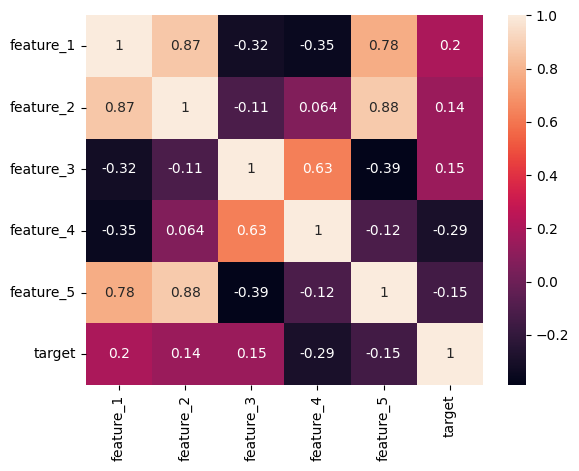

In [8]:
process.collinear(method='pearson', show=True, threshold=0.85)

In [9]:
train, test = splitter(df=df, target='target', test_size=0.25)

_____________Shape - Train vs Test_____________
Train dataset :

Dependent feature = (7, 5)
Independent Feature = (7,)
Test dataset :

Dependent feature = (3, 5)
Independent Feature = (3,)


In [10]:
cherry = Orchestrator(
    
    problem_statement='regression',
    focus_regressor='rmse',
    file_dir='model',
    train = train,
    test = test

)

In [11]:
cherry.orchestrate()

-------------Demorgraphics-------------
Best Model : SVR
SVR Accuracy(R2 SCore) : -0.6217486321144892
SVR RMSE : 66.03561067684166
---------------------------------------


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [12]:
cherry.critique()

cannot access local variable 'message' where it is not associated with a value


In [15]:
model = cherry.topkmodel(access_estimator = 6)

╭──────────────────────────────────────────────────  Top Models ──────────────────────────────────────────────────╮
│                                                    Model Arena                                                  │
│ ╔══════╤════════════════════╤════════════════════╤═══════════════════╤════════════════════╤═══════════════════╗ │
│ ║ Rank │     estimator      │      accuracy      │        mse        │        mae         │       rmse        ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║ 🥇1  │       SVR()        │ -0.62174863211448… │ 4360.701877463404 │ 62.27290755120048  │ 66.03561067684166 ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║ 🥈2  │ KNeighborsRegress… │ -16.3346793388429… │ 46611.02666666667 │ 210.60000000000002 │ 215.895869962041… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║ 🥉3  │ RandomForestRegre… │ -27.88076678099174 │    77657.1729     │       245.09       │ 278.6703660240895 ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  4   │ LinearRegression() │ -38.58944800685111 │ 106451.6268628663 │ 246.9057084607539  │ 326.269255160314… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  5   │ AdaBoostRegressor… │ -57.5287913223140… │ 157377.416666666… │       275.5        │ 396.7082261141892 ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  6   │ GradientBoostingR… │ -65.93007572262667 │ 179967.5369430628 │ 355.5144034067726  │ 424.225808907311… ║ │
│ ╟──────┼────────────────────┼────────────────────┼───────────────────┼────────────────────┼───────────────────╢ │
│ ║  7   │ XGBRegressor(base… │ -133.3524932861328 │   361258.90625    │ 513.9981689453125  │ 601.0481729861592 ║ │
│ ║      │   booster=None,    │                    │                   │                    │                   ║ │
│ ║      │  callbacks=None,   │                    │                   │                    │                   ║ │
│ ║      │              cols… │                    │                   │                    │                   ║ │
│ ║      │ colsample_bynode=… │                    │                   │                    │                   ║ │
│ ║      │              cols… │                    │                   │                    │                   ║ │
│ ║      │    device=None,    │                    │                   │                    │                   ║ │
│ ║      │ early_stopping_ro… │                    │                   │                    │                   ║ │
│ ║      │              enab… │                    │                   │                    │                   ║ │
│ ║      │ eval_metric=None,  │                    │                   │                    │                   ║ │
│ ║      │ feature_types=Non… │                    │                   │                    │                   ║ │
│ ║      │              feat… │                    │                   │                    │                   ║ │
│ ║      │    gamma=None,     │                    │                   │                    │                   ║ │
│ ║      │ grow_policy=None,  │                    │                   │                    │                   ║ │
│ ║      │              impo… │                    │                   │                    │                   ║ │
│ ║      │ interaction_const… │                    │                   │                    │                   ║ │
│ ║      │              lear… │                    │                   │                    │                   ║ │
│ ║      │   max_bin=None,    │                    │       

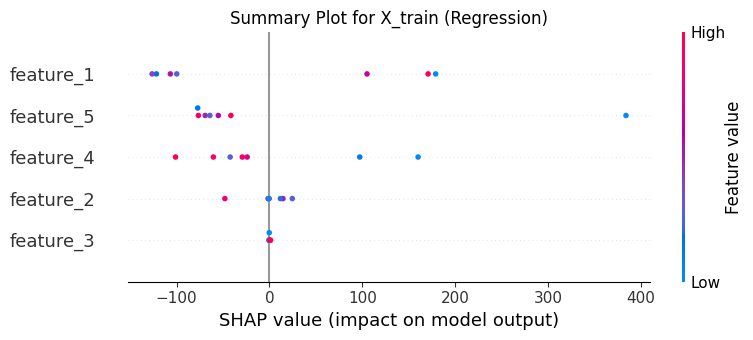

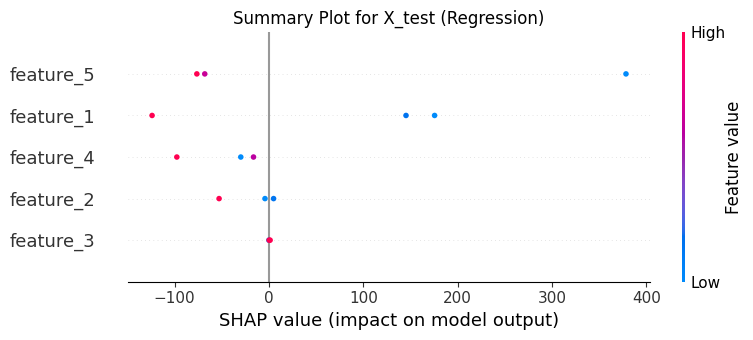

In [16]:
cherry.auto_explain(model=model)

In [17]:
import pandas as pd
df = pd.DataFrame({
    "feature_1": [12, 45, 23, 67, 34, 89, 54, 21, 76, 38, 49, 62, 28, 90, 55],
    "feature_2": [100, 200, 150, 300, 250, 400, 350, 120, 370, 220, 260, 310, 180, 420, 360],
    "feature_3": [1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0],
    "feature_4": [5, 3, 6, 2, 7, 1, 8, 4, 9, 5, 6, 7, 3, 2, 8],
    "feature_5": [10, 20, 15, 25, 18, 30, 28, 12, 27, 19, 22, 24, 12, 35, 29],
    # "target":     [100, 111, 222, 500, 899, 641, 112, 400, 10000, 80000, 190, 133, 112, 41, 1]
    "target" : [1, 2, 0, 0, 1, 2, 1, 0, 2, 1, 2, 1, 1, 2, 0]
})

train, test = splitter(df= df ,target='target', test_size=0.24)
cherry = Orchestrator(
    problem_statement='classification',
    focus_classifier='precision',
    train=train,
    test=test,
    file_dir='model'
)
model = cherry.orchestrate()
# model = cherry.topkmodel(access_estimator=1)
model

_____________Shape - Train vs Test_____________
Train dataset :

Dependent feature = (11, 5)
Independent Feature = (11,)
Test dataset :

Dependent feature = (4, 5)
Independent Feature = (4,)
-------------Demographics-------------
Best Model : RandomForestClassifier(precision)
RandomForestClassifier Accuracy : 0.5
RandomForestClassifier Precision : 1.0
RandomForestClassifier Recall : 0.5
RandomForestClassifier f1score : 0.625
---------------------------------------


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
impact, shap_values = explainer(model=model, impact_type='all', data=train[0])

In [19]:
shap_values

.values =
array([[[-0.07282548, -0.07186655,  0.14469203],
        [-0.1046612 , -0.04381568,  0.14847688],
        [ 0.06460865, -0.0248907 , -0.03971795],
        [-0.01586265, -0.04159235,  0.057455  ],
        [ 0.03237704, -0.06510745,  0.03273041]],

       [[-0.03279908, -0.09529819,  0.12809727],
        [-0.04440548, -0.05429825,  0.09870373],
        [-0.08764063,  0.04517291,  0.04246772],
        [-0.04218709,  0.04277171, -0.00058462],
        [ 0.00066865, -0.05562092,  0.05495227]],

       [[ 0.17502958, -0.03160749, -0.14342209],
        [ 0.11991769, -0.0488069 , -0.07111079],
        [-0.04628746,  0.03814749,  0.00813997],
        [ 0.07384157, -0.08153733,  0.00769576],
        [ 0.11113498,  0.00653151, -0.11766649]],

       [[-0.10325999,  0.01758234,  0.08567765],
        [-0.04485601,  0.02810078,  0.01675523],
        [-0.05391727,  0.03542481,  0.01849246],
        [ 0.01742652, -0.06003152,  0.042605  ],
        [-0.0717569 , -0.04834913,  0.12010603]],

  

In [20]:
import shap
explainer = shap.TreeExplainer(model, train[0])
classk = explainer(test[0]).values[:,:, 0]
classk

array([[-0.11378788, -0.07333333, -0.05090909,  0.03772727, -0.07878788],
       [ 0.08568182,  0.01      , -0.10159091, -0.03962121,  0.00643939],
       [ 0.1690909 ,  0.12439394, -0.04386364,  0.06734848,  0.06393939],
       [-0.05992424, -0.10719697, -0.06628788,  0.02333333,  0.01098485]])

In [21]:
for i in range(n_features):
    for j in range(n_classes):
        classk = explainer(test[0]).values[i, : , j]
        print(classk)


NameError: name 'n_features' is not defined

In [22]:
explainer(test[0]).values[1, :, 2]

array([-0.04598485, -0.06143939,  0.04143939, -0.0394697 ,  0.05636364])

In [23]:
val = explainer(test[0]).values
val

array([[[-0.11378788,  0.14492424, -0.03113636],
        [-0.07333333,  0.06386363,  0.0094697 ],
        [-0.05090909,  0.035     ,  0.01590909],
        [ 0.03772727, -0.09643939,  0.05871212],
        [-0.07878788,  0.10083333, -0.02204545]],

       [[ 0.08568182, -0.03969697, -0.04598485],
        [ 0.01      ,  0.05143939, -0.06143939],
        [-0.10159091,  0.06015151,  0.04143939],
        [-0.03962121,  0.07909091, -0.0394697 ],
        [ 0.00643939, -0.06280303,  0.05636364]],

       [[ 0.1690909 , -0.0455303 , -0.1235606 ],
        [ 0.12439394, -0.06295454, -0.06143939],
        [-0.04386364,  0.0244697 ,  0.01939394],
        [ 0.06734848, -0.08742424,  0.02007576],
        [ 0.06393939,  0.05962121, -0.1235606 ]],

       [[-0.05992424, -0.10181818,  0.16174242],
        [-0.10719697, -0.05674242,  0.16393939],
        [-0.06628788,  0.02318182,  0.04310606],
        [ 0.02333333, -0.05810606,  0.03477273],
        [ 0.01098485, -0.04833333,  0.03734848]]])

In [24]:
import numpy as np

In [25]:
vals = np.abs(val).mean(axis = (0, 2))


In [26]:
val

array([[[-0.11378788,  0.14492424, -0.03113636],
        [-0.07333333,  0.06386363,  0.0094697 ],
        [-0.05090909,  0.035     ,  0.01590909],
        [ 0.03772727, -0.09643939,  0.05871212],
        [-0.07878788,  0.10083333, -0.02204545]],

       [[ 0.08568182, -0.03969697, -0.04598485],
        [ 0.01      ,  0.05143939, -0.06143939],
        [-0.10159091,  0.06015151,  0.04143939],
        [-0.03962121,  0.07909091, -0.0394697 ],
        [ 0.00643939, -0.06280303,  0.05636364]],

       [[ 0.1690909 , -0.0455303 , -0.1235606 ],
        [ 0.12439394, -0.06295454, -0.06143939],
        [-0.04386364,  0.0244697 ,  0.01939394],
        [ 0.06734848, -0.08742424,  0.02007576],
        [ 0.06393939,  0.05962121, -0.1235606 ]],

       [[-0.05992424, -0.10181818,  0.16174242],
        [-0.10719697, -0.05674242,  0.16393939],
        [-0.06628788,  0.02318182,  0.04310606],
        [ 0.02333333, -0.05810606,  0.03477273],
        [ 0.01098485, -0.04833333,  0.03734848]]])

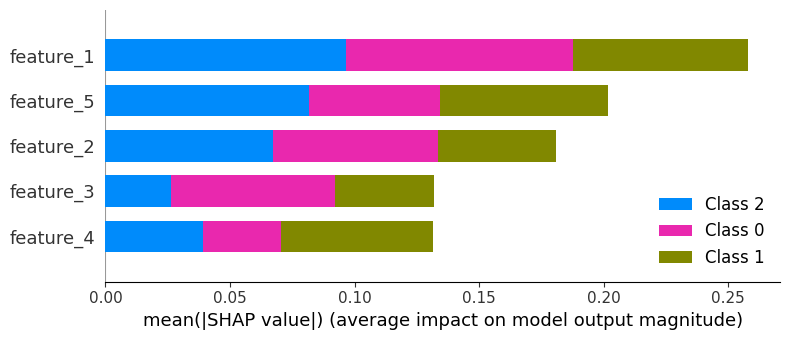

In [27]:
summary_plot(data=test[0])

In [28]:
from cherrypick.explain import explainer
res, exp = explainer(data=train[0], impact_type='all', model=model)

In [29]:
exp

.values =
array([[[-0.07282548, -0.07186655,  0.14469203],
        [-0.1046612 , -0.04381568,  0.14847688],
        [ 0.06460865, -0.0248907 , -0.03971795],
        [-0.01586265, -0.04159235,  0.057455  ],
        [ 0.03237704, -0.06510745,  0.03273041]],

       [[-0.03279908, -0.09529819,  0.12809727],
        [-0.04440548, -0.05429825,  0.09870373],
        [-0.08764063,  0.04517291,  0.04246772],
        [-0.04218709,  0.04277171, -0.00058462],
        [ 0.00066865, -0.05562092,  0.05495227]],

       [[ 0.17502958, -0.03160749, -0.14342209],
        [ 0.11991769, -0.0488069 , -0.07111079],
        [-0.04628746,  0.03814749,  0.00813997],
        [ 0.07384157, -0.08153733,  0.00769576],
        [ 0.11113498,  0.00653151, -0.11766649]],

       [[-0.10325999,  0.01758234,  0.08567765],
        [-0.04485601,  0.02810078,  0.01675523],
        [-0.05391727,  0.03542481,  0.01849246],
        [ 0.01742652, -0.06003152,  0.042605  ],
        [-0.0717569 , -0.04834913,  0.12010603]],

  

In [30]:
shap_values

.values =
array([[[-0.07282548, -0.07186655,  0.14469203],
        [-0.1046612 , -0.04381568,  0.14847688],
        [ 0.06460865, -0.0248907 , -0.03971795],
        [-0.01586265, -0.04159235,  0.057455  ],
        [ 0.03237704, -0.06510745,  0.03273041]],

       [[-0.03279908, -0.09529819,  0.12809727],
        [-0.04440548, -0.05429825,  0.09870373],
        [-0.08764063,  0.04517291,  0.04246772],
        [-0.04218709,  0.04277171, -0.00058462],
        [ 0.00066865, -0.05562092,  0.05495227]],

       [[ 0.17502958, -0.03160749, -0.14342209],
        [ 0.11991769, -0.0488069 , -0.07111079],
        [-0.04628746,  0.03814749,  0.00813997],
        [ 0.07384157, -0.08153733,  0.00769576],
        [ 0.11113498,  0.00653151, -0.11766649]],

       [[-0.10325999,  0.01758234,  0.08567765],
        [-0.04485601,  0.02810078,  0.01675523],
        [-0.05391727,  0.03542481,  0.01849246],
        [ 0.01742652, -0.06003152,  0.042605  ],
        [-0.0717569 , -0.04834913,  0.12010603]],

  

In [31]:
res = res.sort_values(by='Features')
res

,Features,Overall_Impact
0,feature_1,0.085949
1,feature_2,0.060243
2,feature_3,0.043979
3,feature_4,0.043788
4,feature_5,0.067226


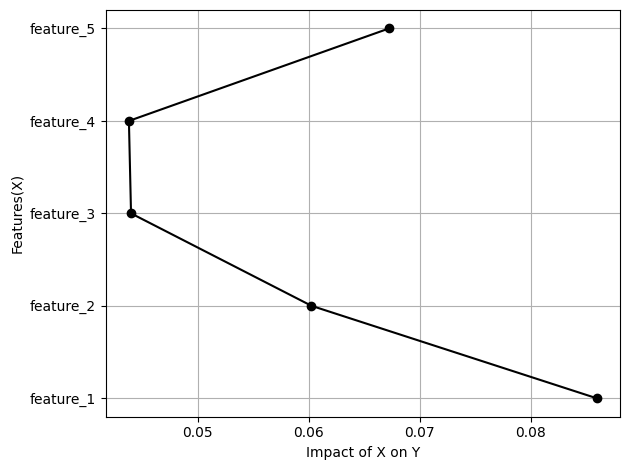

In [32]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.plot(res['Overall_Impact'] , res["Features"], marker='o', color='black')
plt.xlabel("Impact of X on Y")
plt.ylabel("Features(X)")
plt.grid()
plt.tight_layout()

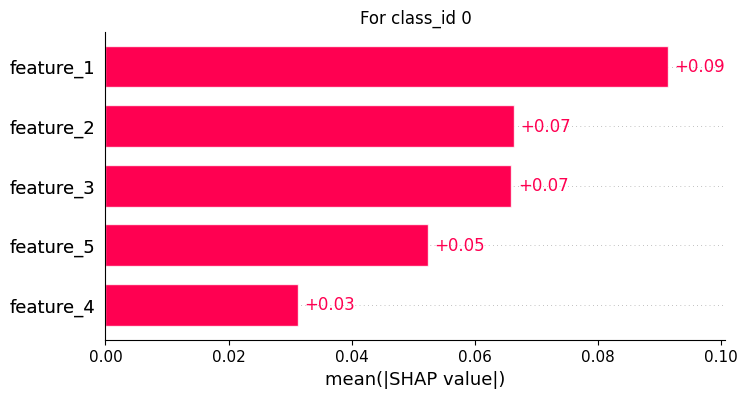

<Figure size 640x480 with 0 Axes>

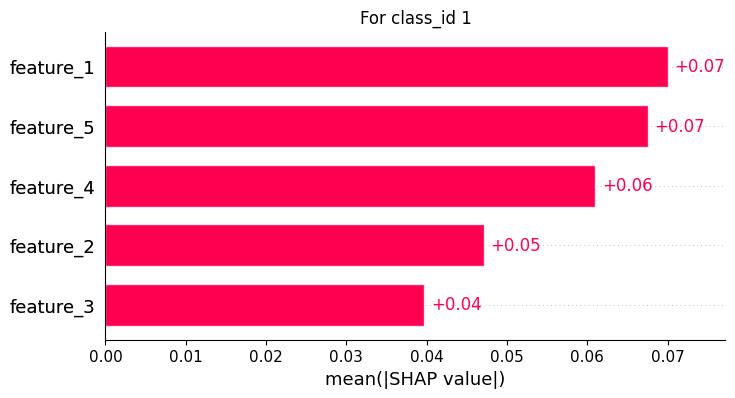

<Figure size 640x480 with 0 Axes>

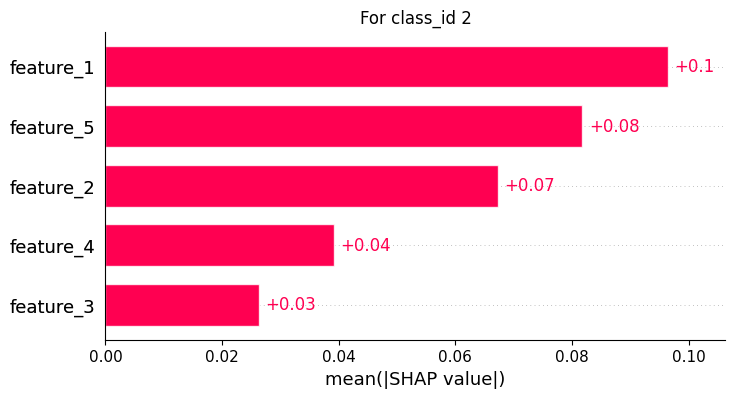

<Figure size 640x480 with 0 Axes>

In [33]:
bar_plot(n_classes=3)

In [34]:
len(train[1].unique())

3

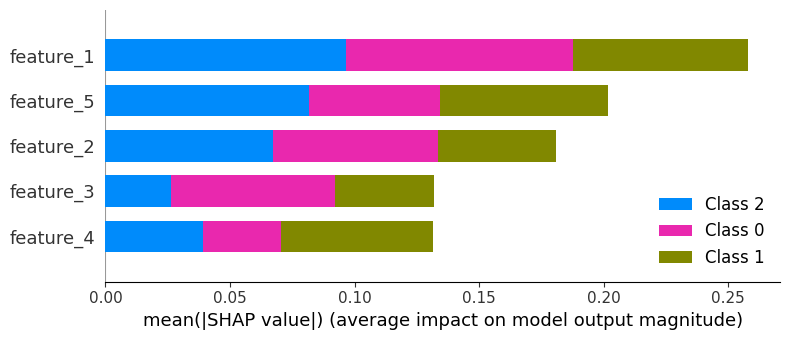

In [35]:
summary_plot(data=train[0])

In [36]:
shap_values

.values =
array([[[-0.07282548, -0.07186655,  0.14469203],
        [-0.1046612 , -0.04381568,  0.14847688],
        [ 0.06460865, -0.0248907 , -0.03971795],
        [-0.01586265, -0.04159235,  0.057455  ],
        [ 0.03237704, -0.06510745,  0.03273041]],

       [[-0.03279908, -0.09529819,  0.12809727],
        [-0.04440548, -0.05429825,  0.09870373],
        [-0.08764063,  0.04517291,  0.04246772],
        [-0.04218709,  0.04277171, -0.00058462],
        [ 0.00066865, -0.05562092,  0.05495227]],

       [[ 0.17502958, -0.03160749, -0.14342209],
        [ 0.11991769, -0.0488069 , -0.07111079],
        [-0.04628746,  0.03814749,  0.00813997],
        [ 0.07384157, -0.08153733,  0.00769576],
        [ 0.11113498,  0.00653151, -0.11766649]],

       [[-0.10325999,  0.01758234,  0.08567765],
        [-0.04485601,  0.02810078,  0.01675523],
        [-0.05391727,  0.03542481,  0.01849246],
        [ 0.01742652, -0.06003152,  0.042605  ],
        [-0.0717569 , -0.04834913,  0.12010603]],

  

In [37]:
type(model)

sklearn.ensemble._forest.RandomForestClassifier